# Odev2: CIFAR-10 Goruntu Siniflandirma

Bu notebook, PyTorch kullanilarak tasarlanmis CNN modellerini ve klasik makine ogrenmesi hibritlerini (Odev1 standartlarina uygun, tam OOP kapsullemesiyle) icermektedir.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')

from src.data_preprocessing import get_cifar10_loaders, CIFAR10_CLASSES
from src.cnn_models import BasicCNN, ImprovedCNN, get_vgg16_transfer
from src.classifier import CNNClassifier
from src.hybrid import HybridClassifier
from src.metrics import plot_training_curves, evaluate_and_plot_cm

# Hiperparametreler
EPOCHS = 10
EPOCHS_VGG = 5
BATCH_SIZE = 128
LR = 0.001
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Moduller ve kutuphaneler yuklendi.")

Moduller ve kutuphaneler yuklendi.


## 1. Veri Seti Hazirligi

In [2]:
train_loader, test_loader = get_cifar10_loaders(batch_size=BATCH_SIZE)
classes = CIFAR10_CLASSES
print(f"Siniflar: {classes}")

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Siniflar: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


### 1.1 Veri Setinden Ornek Gorseller

Asagida egitim veri setinden rastgele secilmis 16 adet ornek yer almaktadir.

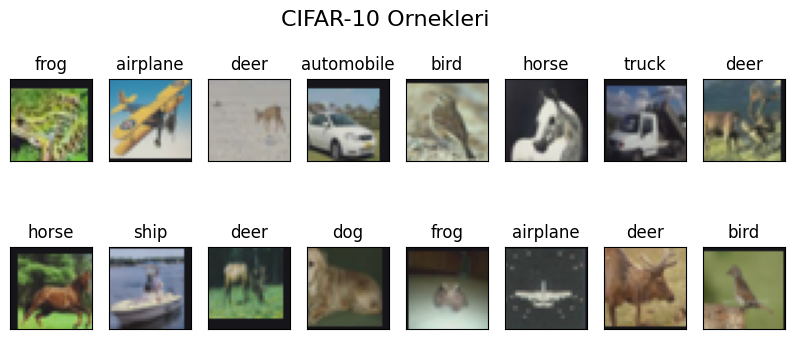

In [3]:
def show_samples(loader, classes, title="CIFAR-10 Ornekleri"):
    images, labels = next(iter(loader))
    images = images.numpy()
    fig = plt.figure(figsize=(10, 4))
    for i in np.arange(16):
        ax = fig.add_subplot(2, 8, i+1, xticks=[], yticks=[])
        # Normalize edilmis gorseli geri dondur
        img = images[i].transpose((1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(classes[labels[i]])
    plt.suptitle(title, fontsize=16)
    plt.show()

show_samples(train_loader, classes)

## 2. Model 1 (Temel CNN) Egitimi

Model 1 egitiliyor...


Epoch 1/10 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   0%|          | 1/391 [00:00<06:13,  1.04it/s]

Epoch 1/10 [Train]:   1%|          | 2/391 [00:01<03:01,  2.14it/s]

Epoch 1/10 [Train]:   1%|          | 3/391 [00:01<02:00,  3.23it/s]

...

Epoch 10/10 [Train]:  97%|█████████▋| 381/391 [00:13<00:00, 29.49it/s]

Epoch 10/10 [Train]:  98%|█████████▊| 384/391 [00:13<00:00, 29.56it/s]

Epoch 10/10 [Train]:  99%|█████████▉| 388/391 [00:13<00:00, 29.93it/s]

Epoch 10/10 - Train Loss: 0.9211, Train Acc: 67.19%

 | Val Loss: 0.8412, Val Acc: 70.75%


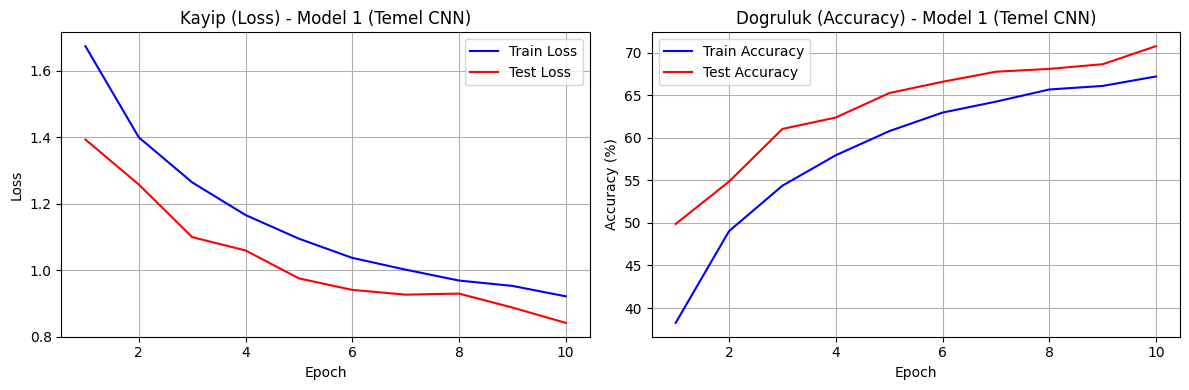


Model 1 - Confusion Matrix - Siniflandirma Raporu:
              precision    recall  f1-score   support

    airplane       0.72      0.77      0.74      1000
  automobile       0.82      0.79      0.81      1000
        bird       0.72      0.49      0.58      1000
         cat       0.54      0.49      0.52      1000
        deer       0.69      0.63      0.66      1000
         dog       0.54      0.70      0.61      1000
        frog       0.75      0.79      0.77      1000
       horse       0.76      0.77      0.77      1000
        ship       0.83      0.81      0.82      1000
       truck       0.73      0.84      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



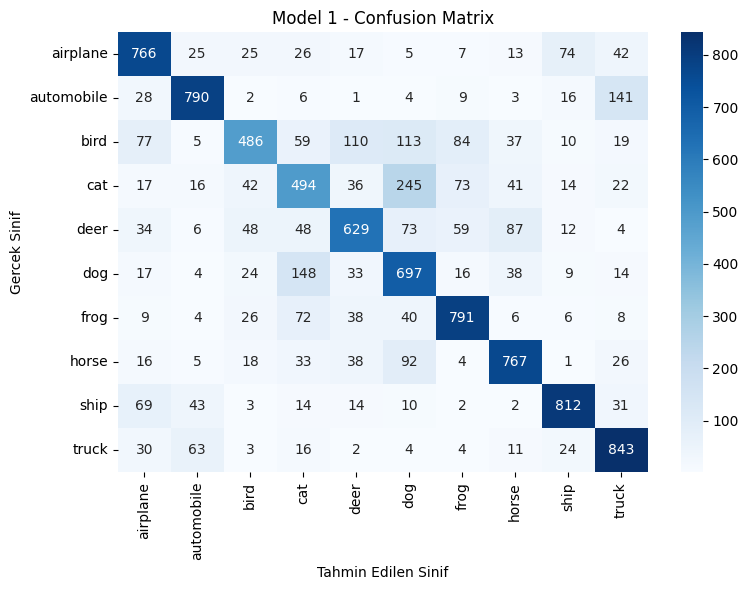

In [4]:
# Model objesi ve OOP Classifier saricisi
model1_arch = BasicCNN(num_classes=10)
clf1 = CNNClassifier(model=model1_arch, lr=LR)

print("Model 1 egitiliyor...")
history1 = clf1.fit(train_loader, val_loader=test_loader, epochs=EPOCHS)
plot_training_curves(history1, title="Model 1 (Temel CNN)")

# Degerlendirme
y_true1, y_pred1 = clf1.predict(test_loader)
evaluate_and_plot_cm(y_true1, y_pred1, classes, title="Model 1 - Confusion Matrix")

## 3. Model 2 (Iyilestirilmis CNN) Egitimi

Dropout ve BatchNorm iceren yapi.

Model 2 egitiliyor...


Epoch 1/10 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   1%|          | 2/391 [00:00<00:23, 16.47it/s]

Epoch 1/10 [Train]:   1%|          | 4/391 [00:00<00:21, 17.84it/s]

Epoch 1/10 [Train]:   2%|▏         | 6/391 [00:00<00:21, 18.24it/s]

...

Epoch 10/10 [Train]:  98%|█████████▊| 383/391 [00:14<00:00, 27.09it/s]

Epoch 10/10 [Train]:  99%|█████████▊| 386/391 [00:14<00:00, 27.41it/s]

Epoch 10/10 [Train]:  99%|█████████▉| 389/391 [00:14<00:00, 27.36it/s]

Epoch 10/10 - Train Loss: 1.3524, Train Acc: 51.41%

 | Val Loss: 1.0964, Val Acc: 60.72%


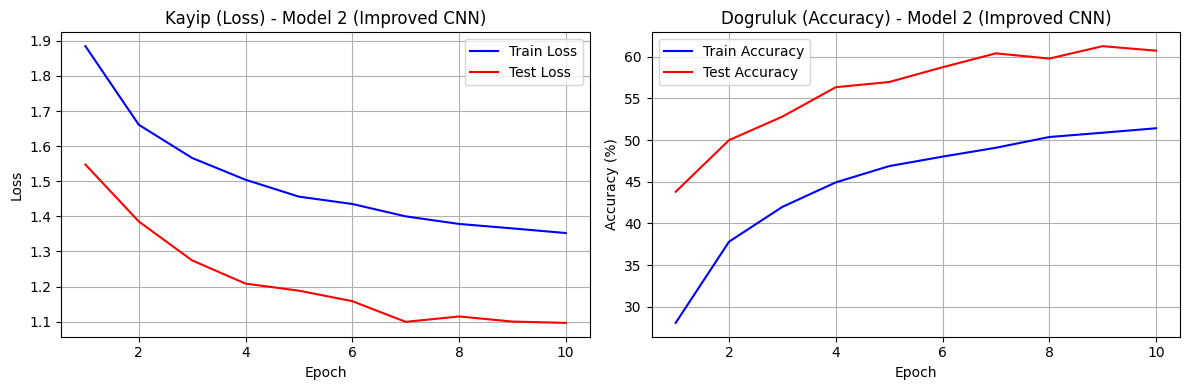


Model 2 - Confusion Matrix - Siniflandirma Raporu:
              precision    recall  f1-score   support

    airplane       0.69      0.69      0.69      1000
  automobile       0.76      0.80      0.78      1000
        bird       0.53      0.27      0.36      1000
         cat       0.39      0.19      0.25      1000
        deer       0.55      0.44      0.49      1000
         dog       0.41      0.75      0.53      1000
        frog       0.82      0.63      0.71      1000
       horse       0.54      0.81      0.64      1000
        ship       0.76      0.77      0.77      1000
       truck       0.71      0.73      0.72      1000

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.59     10000
weighted avg       0.61      0.61      0.59     10000



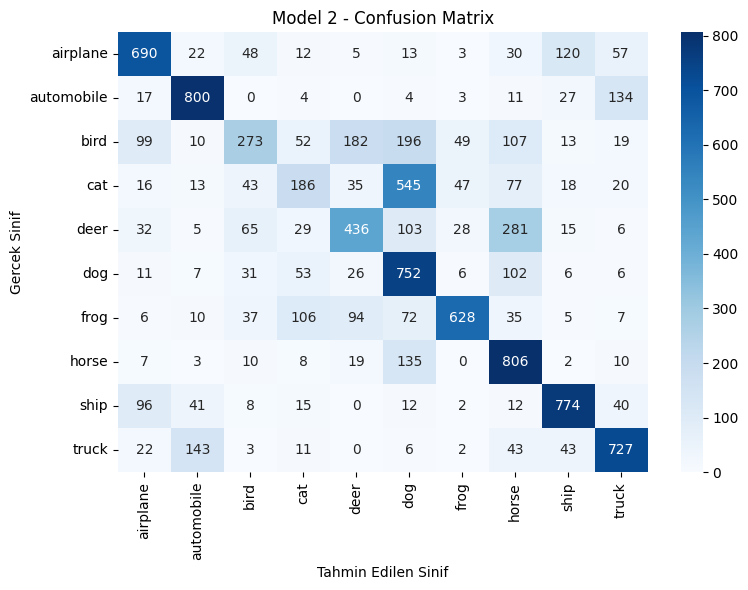

In [5]:
model2_arch = ImprovedCNN(num_classes=10)
clf2 = CNNClassifier(model=model2_arch, lr=LR)

print("Model 2 egitiliyor...")
history2 = clf2.fit(train_loader, val_loader=test_loader, epochs=EPOCHS)
plot_training_curves(history2, title="Model 2 (Improved CNN)")

# Degerlendirme
y_true2, y_pred2 = clf2.predict(test_loader)
evaluate_and_plot_cm(y_true2, y_pred2, classes, title="Model 2 - Confusion Matrix")

## 4. Model 3 (VGG-16 Transfer Learning)

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Model 3 (VGG-16) egitiliyor...


Epoch 1/5 [Train]:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 1/782 [00:00<06:48,  1.91it/s]

Epoch 1/5 [Train]:   0%|          | 2/782 [00:00<06:14,  2.08it/s]

...

Epoch 5/5 [Train]: 100%|█████████▉| 780/782 [07:51<00:01,  1.51it/s]

Epoch 5/5 [Train]: 100%|█████████▉| 781/782 [07:52<00:00,  1.51it/s]

Epoch 5/5 [Train]: 100%|██████████| 782/782 [07:52<00:00,  1.89it/s]

Epoch 5/5 - Train Loss: 0.5604, Train Acc: 82.78%

 | Val Loss: 0.4453, Val Acc: 86.26%


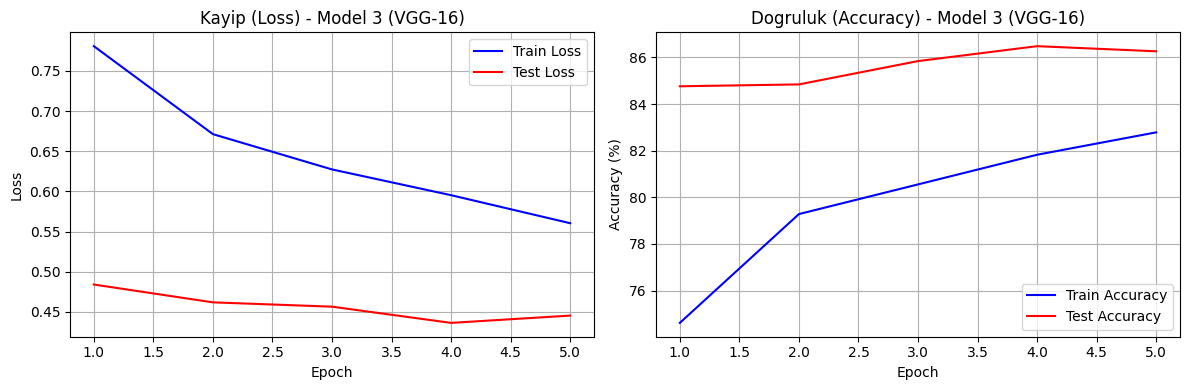


Model 3 - Confusion Matrix - Siniflandirma Raporu:
              precision    recall  f1-score   support

    airplane       0.89      0.89      0.89      1000
  automobile       0.87      0.96      0.91      1000
        bird       0.95      0.70      0.80      1000
         cat       0.75      0.74      0.75      1000
        deer       0.75      0.90      0.82      1000
         dog       0.85      0.79      0.82      1000
        frog       0.85      0.94      0.89      1000
       horse       0.90      0.91      0.90      1000
        ship       0.96      0.90      0.93      1000
       truck       0.92      0.90      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



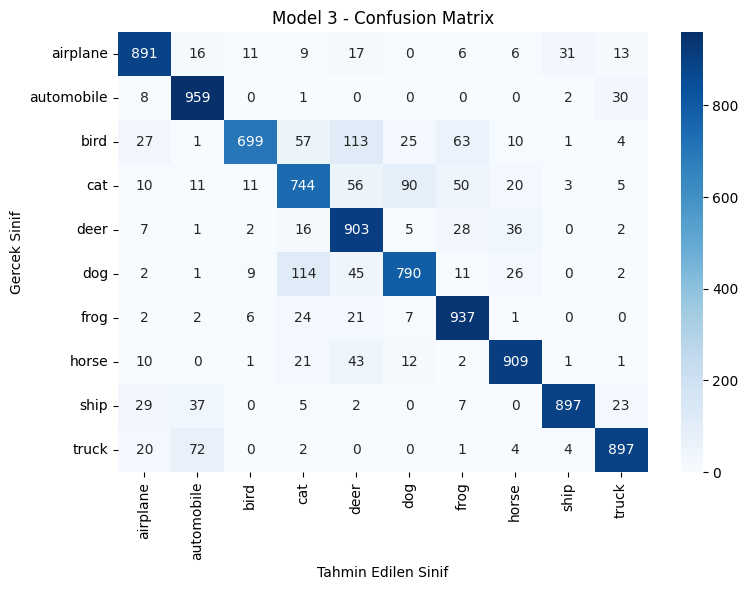

In [6]:
# VGG-16 icin ozel loader (224x224)
train_loader_vgg, test_loader_vgg = get_cifar10_loaders(batch_size=64, resize_224=True)

model3_arch = get_vgg16_transfer(num_classes=10)
clf3 = CNNClassifier(model=model3_arch, lr=LR)

print("Model 3 (VGG-16) egitiliyor...")
history3 = clf3.fit(train_loader_vgg, val_loader=test_loader_vgg, epochs=EPOCHS_VGG)
plot_training_curves(history3, title="Model 3 (VGG-16)")

y_true3, y_pred3 = clf3.predict(test_loader_vgg)
evaluate_and_plot_cm(y_true3, y_pred3, classes, title="Model 3 - Confusion Matrix")

## 5. Model 4 (Hibrit - SVM ve Random Forest)

[SVM] Egitim seti ozellikleri cikariliyor...


-> Ozellikler kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\train_features.npy (Boyut: (50000, 2048))
-> Etiketler kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\train_labels.npy (Boyut: (50000,))
[SVM] Makine ogrenmesi modeli egitiliyor...


-> Egitim tamamlandi.
[SVM] Test seti ozellikleri cikariliyor...


-> Test Ozellikleri kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\test_features.npy (Boyut: (10000, 2048))
-> Test Etiketleri kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\test_labels.npy (Boyut: (10000,))



Model 4 (Hibrit SVM) - Siniflandirma Raporu:
              precision    recall  f1-score   support

    airplane       0.70      0.77      0.73      1000
  automobile       0.79      0.87      0.83      1000
        bird       0.59      0.56      0.58      1000
         cat       0.54      0.53      0.54      1000
        deer       0.66      0.63      0.65      1000
         dog       0.61      0.65      0.63      1000
        frog       0.75      0.81      0.78      1000
       horse       0.81      0.73      0.77      1000
        ship       0.82      0.80      0.81      1000
       truck       0.84      0.76      0.80      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



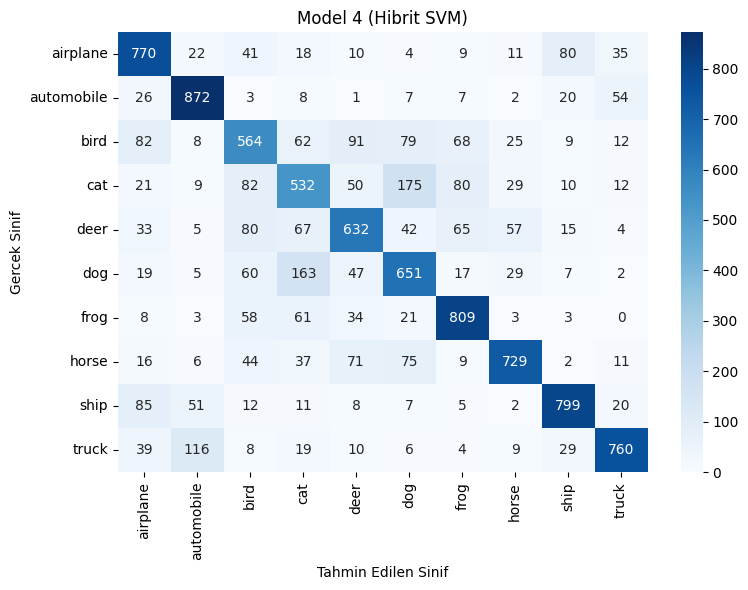

[RF] Egitim seti ozellikleri cikariliyor...


-> Ozellikler kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\train_features.npy (Boyut: (50000, 2048))
-> Etiketler kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\train_labels.npy (Boyut: (50000,))
[RF] Makine ogrenmesi modeli egitiliyor...


-> Egitim tamamlandi.
[RF] Test seti ozellikleri cikariliyor...


-> Test Ozellikleri kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\test_features.npy (Boyut: (10000, 2048))
-> Test Etiketleri kaydedildi: C:\Users\HP\OneDrive\Masaüstü\DL_Lab2\Odev2\data\test_labels.npy (Boyut: (10000,))



Model 4 (Hibrit RF) - Siniflandirma Raporu:
              precision    recall  f1-score   support

    airplane       0.58      0.59      0.58      1000
  automobile       0.59      0.71      0.65      1000
        bird       0.43      0.34      0.38      1000
         cat       0.33      0.30      0.32      1000
        deer       0.49      0.42      0.45      1000
         dog       0.45      0.54      0.49      1000
        frog       0.59      0.69      0.64      1000
       horse       0.64      0.52      0.58      1000
        ship       0.66      0.68      0.67      1000
       truck       0.61      0.62      0.61      1000

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000



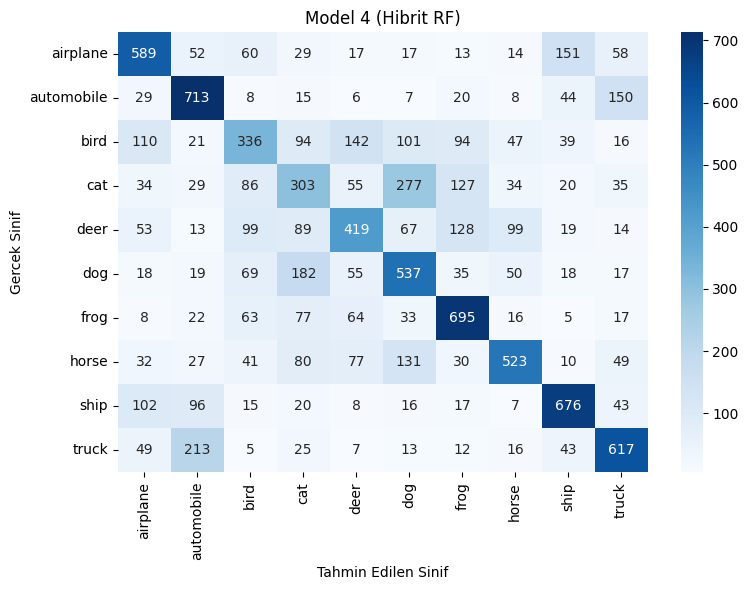

In [7]:
# SVM Hibrit
hybrid_svm = HybridClassifier(feature_extractor=clf2.model, ml_type='svm')
hybrid_svm.fit(train_loader)

y_true_svm, y_pred_svm = hybrid_svm.predict(test_loader)
evaluate_and_plot_cm(y_true_svm, y_pred_svm, classes, title="Model 4 (Hibrit SVM)")

# RF Hibrit
hybrid_rf = HybridClassifier(feature_extractor=clf2.model, ml_type='rf')
hybrid_rf.fit(train_loader)

y_true_rf, y_pred_rf = hybrid_rf.predict(test_loader)
evaluate_and_plot_cm(y_true_rf, y_pred_rf, classes, title="Model 4 (Hibrit RF)")